# CSC2541

End-to-end pipeline: download ChEMBL molecules → featurize → generate analogs via PrexSyn → score results.

Each section can be run independently if intermediate files already exist.

In [1]:
import pathlib
import sys

# ── resolve project root ───────────────────────────────────────────────────────
_root = pathlib.Path.cwd()
if not (_root / "src").exists():
    _root = _root.parent
for _p in ["src/utils", "src/generation", "src/evaluation"]:
    sys.path.insert(0, str(_root / _p))

# ── paths ──────────────────────────────────────────────────────────────────────
DATA_DIR         = _root / "data"
CHEMBL_FULL_CSV  = DATA_DIR / "chembl_full.csv"
CHEMBL_CSV       = DATA_DIR / "chembl_sampled.csv"
CHEMBL_CACHE     = DATA_DIR / "chembl_35_chemreps.txt.gz"
FEATURES_NPZ     = DATA_DIR / "chembl_features.npz"
SAMPLES_JSON     = DATA_DIR / "prexsyn_sampled.json"
SCORES_CSV       = DATA_DIR / "chembl_scores.csv"
AIZYNTH_DIR      = DATA_DIR / "aizynthfinder"

# ── pipeline settings ─────────────────────────────────────────────────────────
NUM_MOLECULES = 1000
SEED          = 42
NUM_SAMPLES   = 64
API_URL       = "http://100.65.172.100:8011/sample"
LIMIT         = None       # set to e.g. 10 for a quick test run

## 1. Download ChEMBL

Downloads the full ChEMBL release, filters for valid drug-like organic molecules, and saves the complete set.  
This file is large (~1.8M molecules) but only needs to be downloaded once — reuse it across experiments by changing `SEED` or `NUM_MOLECULES` in the next cell.  
Skipped automatically if the output file already exists.

In [2]:
from download_chembl import download

if CHEMBL_FULL_CSV.exists():
    print(f"Already exists, skipping download: {CHEMBL_FULL_CSV}")
else:
    download(output=CHEMBL_FULL_CSV, cache=CHEMBL_CACHE)

Already exists, skipping download: /Users/acmaro/Desktop/CSC2541-Project/data/chembl_full.csv


## 2. Sample from ChEMBL

Randomly samples `NUM_MOLECULES` from the full filtered set.  
Change `SEED` or `NUM_MOLECULES` above and re-run this cell to get a different subset — no need to re-download.

In [3]:
from download_chembl import sample as sample_chembl

sample_chembl(input=CHEMBL_FULL_CSV, output=CHEMBL_CSV, num_molecules=NUM_MOLECULES, seed=SEED)

Loaded 1,794,749 molecules from /Users/acmaro/Desktop/CSC2541-Project/data/chembl_full.csv
Sampled 1000 molecules → /Users/acmaro/Desktop/CSC2541-Project/data/chembl_sampled.csv


PosixPath('/Users/acmaro/Desktop/CSC2541-Project/data/chembl_sampled.csv')

## 3. Featurize

Computes ECFP4, FCFP4, RDKit descriptors, and BRICS fragment fingerprints for each molecule.  
Output is a `.npz` file with arrays shaped `(N, ...)`.  
Skipped if the output file already exists.

In [4]:
from featurize_chembl import featurize

featurize(input=CHEMBL_CSV, output=FEATURES_NPZ)

Loaded 1000 molecules from /Users/acmaro/Desktop/CSC2541-Project/data/chembl_sampled.csv


Featurizing: 100%|██████████| 1000/1000 [00:08<00:00, 119.62it/s]


Featurized 1000 molecules.
Saved features to: /Users/acmaro/Desktop/CSC2541-Project/data/chembl_features.npz


PosixPath('/Users/acmaro/Desktop/CSC2541-Project/data/chembl_features.npz')

In [5]:
# Inspect the feature arrays
import numpy as np

data = np.load(FEATURES_NPZ, allow_pickle=True)
for key in ["smiles", "ecfp4", "fcfp4", "rdkit_desc_values", "brics_fps", "brics_exists"]:
    arr = data[key]
    print(f"  {key:25s}: shape={arr.shape}  dtype={arr.dtype}")

  smiles                   : shape=(1000,)  dtype=object
  ecfp4                    : shape=(1000, 2048)  dtype=float32
  fcfp4                    : shape=(1000, 2048)  dtype=float32
  rdkit_desc_values        : shape=(1000, 43)  dtype=float32
  brics_fps                : shape=(1000, 8, 2048)  dtype=float32
  brics_exists             : shape=(1000, 8)  dtype=bool


## 4. Generate Analogs

Sends each molecule's features to the PrexSyn `/sample` API (QuerySampler with product-of-experts over all 5 properties).  
Make sure the Docker container is running: `docker start prexsyn`  
Set `LIMIT` above to a small number (e.g. 10) for a quick test.

In [6]:
import urllib.request

# Check API health before running
try:
    resp = urllib.request.urlopen("http://100.65.172.100:8011/health", timeout=5)
    print("API status:", resp.read().decode())
except Exception as e:
    print(f"API not reachable: {e}\nStart with: docker start prexsyn")

API status: {"status":"ok"}


In [7]:
from sampler import run_batch

run_batch(
    npz=FEATURES_NPZ,
    output=SAMPLES_JSON,
    url=API_URL,
    num_samples=NUM_SAMPLES,
    limit=LIMIT,
)

Processing 1000 molecules → http://100.65.172.100:8011/sample


 74%|███████▍  | 741/1000 [30:44<04:30,  1.04s/it]  

[741] attempt 1/3 failed: timed out


100%|██████████| 1000/1000 [34:50<00:00,  2.09s/it]   

Done: 1000 succeeded, 0 failed
Total generated molecules: 34669
Saved to /Users/acmaro/Desktop/CSC2541-Project/data/prexsyn_sampled.json


PosixPath('/Users/acmaro/Desktop/CSC2541-Project/data/prexsyn_sampled.json')

## 5. Score Generated Molecules

Scores every generated SMILES against its source molecule:
- **Tanimoto** (ECFP4) — structural similarity
- **Desirability** — QED × Lipinski penalty × MW penalty × rotatable bonds penalty
- **Hit** — similar (≥ 0.3) AND drug-like (≥ 0.2) AND novel (< 1.0 Tanimoto)

In [8]:
import json
from scoring import score_results, summarize

results = json.loads(SAMPLES_JSON.read_text())
print(f"Loaded {len(results)} source molecules")
print(f"Total generated: {sum(len(r.get('generated_smiles', [])) for r in results)}")

df = score_results(results, similarity_threshold=0.3, desirability_threshold=0.2, novelty_threshold=1.0)
df.to_csv(SCORES_CSV, index=False)
print(f"Saved {len(df)} scored rows to {SCORES_CSV}")

Loaded 1000 source molecules
Total generated: 34669
Saved 30080 scored rows to /Users/acmaro/Desktop/CSC2541-Project/data/chembl_scores.csv


## 6. Results

In [9]:
# Overall statistics
df[["tanimoto", "qed", "desirability", "is_hit", "is_similar", "is_drug_like", "is_novel"]].describe().round(3)

,tanimoto,qed,desirability
count,30080.000,30080.000,30080.000
mean,0.348,0.407,0.244
std,0.154,0.236,0.264
min,0.000,0.003,0.000
25%,0.239,0.207,0.010
50%,0.319,0.382,0.124
75%,0.424,0.593,0.455
max,1.000,0.948,0.902


In [10]:
# Hit rate summary per source molecule (top 10)
summary = summarize(df)
summary.head(10)

,source_smiles,n_generated,n_hits,hit_rate,mean_tanimoto,max_tanimoto,mean_qed,mean_desirability,n_unique_scaffolds
499,COc1ccc(COc2nc(OCc3ccc(OC)cc3)nc(OCc3ccc(OC)cc...,1,1,1.0,0.346200,0.3462,0.632100,0.612700,1
568,CS(=O)(=O)[C@@H]1CCC[C@H](CN=C=S)C1,7,7,1.0,0.517443,0.5882,0.531500,0.508200,3
638,Cc1cc(N2CCOCC2)n2nc3nc4ccccc4cc3c2n1,9,9,1.0,0.376667,0.4727,0.643511,0.616200,9
106,CC(C)Cn1c(=O)oc2ccccc21,2,2,1.0,0.500000,0.6667,0.659850,0.649550,2
631,Cc1cc(C)nc(N2CC3CCN(C(=O)c4c(F)cccc4-c4ncccn4)...,15,15,1.0,0.537027,0.8000,0.600880,0.445627,12
630,Cc1cc(C)n2nc(N)cc2n1,1,1,1.0,0.350000,0.3500,0.624000,0.618800,1
109,CC(C)N1Cc2c(C(=O)N3CCOCC3)nn(C)c2C1,7,7,1.0,0.607286,0.7826,0.790129,0.761714,3
620,Cc1cc(C(=O)N/N=C/c2cccnc2)c(C)o1,8,8,1.0,0.489862,0.5532,0.534463,0.514962,4
114,CC(C)[C@H](N)C(=O)N1CSC[C@H]1B(O)O,1,1,1.0,0.444400,0.4444,0.512800,0.496000,1
611,Cc1c(C(=O)Nc2cccc(C(F)(F)F)c2)sc2nc3n(c(=O)c12...,2,2,1.0,0.921250,0.9831,0.616400,0.373750,1


In [11]:
total_hits = int(df["is_hit"].sum())
print(f"Total hits : {total_hits} / {len(df)} ({100 * total_hits / len(df):.1f}%)")
print(f"Hit rate   : {df['is_hit'].mean():.3f}")
print(f"Mean Tanimoto : {df['tanimoto'].mean():.3f}")
print(f"Mean QED      : {df['qed'].mean():.3f}")
print(f"Unique scaffolds: {df['scaffold'].nunique()}")

Total hits : 7226 / 30080 (24.0%)
Hit rate   : 0.240
Mean Tanimoto : 0.348
Mean QED      : 0.407
Unique scaffolds: 17508


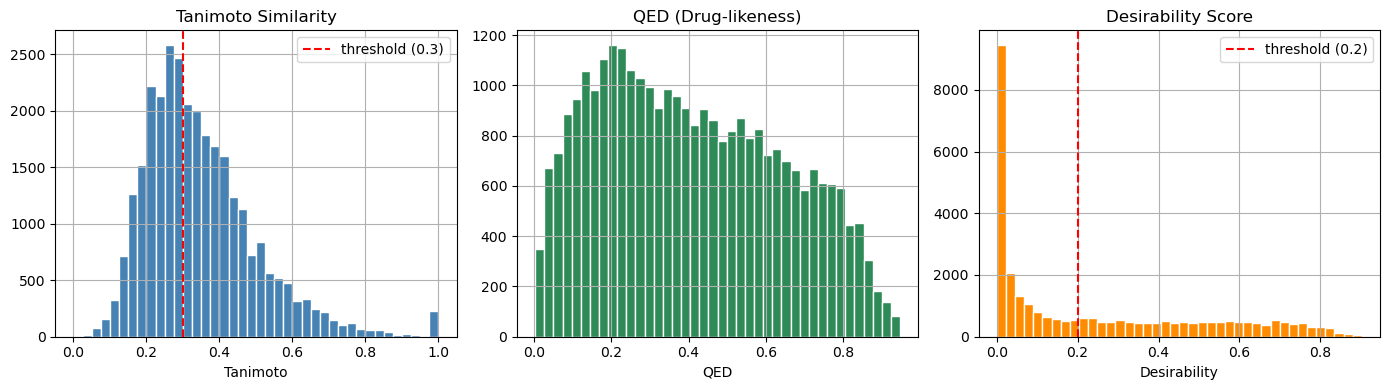

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["tanimoto"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(0.3, color="red", linestyle="--", label="threshold (0.3)")
axes[0].set_title("Tanimoto Similarity")
axes[0].set_xlabel("Tanimoto")
axes[0].legend()

df["qed"].hist(bins=40, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("QED (Drug-likeness)")
axes[1].set_xlabel("QED")

df["desirability"].hist(bins=40, ax=axes[2], color="darkorange", edgecolor="white")
axes[2].axvline(0.2, color="red", linestyle="--", label="threshold (0.2)")
axes[2].set_title("Desirability Score")
axes[2].set_xlabel("Desirability")
axes[2].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "score_distributions.png", dpi=150)
plt.show()

## 7. Reproduce Paper Metrics

Reconstruction rate and mean Tanimoto similarity reported in the PrexSyn paper (sample=64).

In [13]:
import json
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import rdMolDescriptors

def ecfp4(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

# Load raw API output (unfiltered)
results = json.loads(SAMPLES_JSON.read_text())

all_sims      = []   # every generated molecule's Tanimoto
max_tanimotos = []   # best per source molecule
reconstructed = 0

for entry in results:
    src_fp = ecfp4(entry["source_smiles"])
    if src_fp is None:
        continue

    sims = []
    for gen_smi in entry.get("generated_smiles", []):
        gen_fp = ecfp4(gen_smi)
        if gen_fp is None:
            continue
        sim = DataStructs.TanimotoSimilarity(src_fp, gen_fp)
        sims.append(sim)
        all_sims.append(sim)

    if not sims:
        continue

    best = max(sims)
    max_tanimotos.append(best)
    if best == 1.0:
        reconstructed += 1

recon_rate = reconstructed / len(max_tanimotos)

print(f"Molecules evaluated  : {len(max_tanimotos)}")
print(f"Samples per molecule : {NUM_SAMPLES}")
print(f"Total generated      : {len(all_sims)}")
print()
print(f"Recons. %            : {100 * recon_rate:.1f}%")
print(f"Similarity (max/src) : {np.mean(max_tanimotos):.3f}   ← mean of best per source")
print(f"Similarity (all)     : {np.mean(all_sims):.3f}   ← mean of all generated")
print(f"                                         (paper target: 0.73)")

Molecules evaluated  : 1000
Samples per molecule : 64
Total generated      : 34669

Recons. %            : 19.2%
Similarity (max/src) : 0.662   ← mean of best per source
Similarity (all)     : 0.348   ← mean of all generated
                                         (paper target: 0.73)


## 8. Synthesizability Filter (AiZynthFinder)

Uses AiZynthFinder retrosynthesis to evaluate whether generated molecules are synthesizable.  
Models are loaded once and cached for the entire session.

In [16]:
import subprocess

AIZYNTH_DIR.mkdir(parents=True, exist_ok=True)

if not (AIZYNTH_DIR / "uspto_model.onnx").exists():
    print(f"Downloading AiZynthFinder models to {AIZYNTH_DIR} ...")
    subprocess.run(["download_public_data", str(AIZYNTH_DIR)], check=True)
    print("Done.")
else:
    print(f"Models already present: {AIZYNTH_DIR}")

Models already present: /Users/acmaro/Desktop/CSC2541-Project/data/aizynthfinder


In [17]:
import importlib
import synthesizability
importlib.reload(synthesizability)
from synthesizability import score_batch

test_molecules = {
    "Aspirin":      "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen":    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Caffeine":     "Cn1cnc2c1c(=O)n(c(=O)n2C)C",
    "Paclitaxel":   "CC1=C2C(C(=O)C3(C(CC4C(C3C(C(C2(C)C)(CC1OC(=O)C(NC(=O)c5ccccc5)c6ccccc6)O)OC(=O)c7ccccc7)(CO4)OC(C)=O)O)C)OC(=O)C",
    "Penicillin G": "CC1(C(N2C(S1)C(C2=O)NC(=O)Cc3ccccc3)C(=O)O)C",
}

config = str(AIZYNTH_DIR / "config.yml")
results = score_batch(list(test_molecules.values()), config_path=config)

print(f"{'Molecule':<15} {'Solved':<8} {'Routes':<8} {'Top Score'}")
print("-" * 45)
for name, res in zip(test_molecules.keys(), results):
    print(f"{name:<15} {str(res['is_solved']):<8} {res['num_routes']:<8} {res['top_score']:.3f}")

Loading AiZynthFinder models (first call only)...
Ready.
Molecule        Solved   Routes   Top Score
---------------------------------------------
Aspirin         True     46       0.998
Ibuprofen       False    144      0.766
Caffeine        True     57       0.998
Paclitaxel      False    339      0.785
Penicillin G    False    121      0.766
